# Weather Data Pipeline with Python

This notebook builds a simple ETL pipeline using the free Open-Meteo API. It extracts current weather data for major African cities, loads it into Pandas, cleans and validates it, creates features, generates insights, and saves the final outputs as CSV and JSON files.

## Objective

Build a complete ETL (Extract, Transform, Load) pipeline using the Open-Meteo API.

### Project Workflow

1. Extract weather data from API
2. Create a Pandas DataFrame
3. Explore the dataset
4. Clean the data
5. Handle missing values
6. Remove duplicates
7. Transform the data
8. Feature engineering
9. Analyze the data
10. Generate reports
11. Export data to CSV and JSON

---

## Cell 1: Install Dependencies

Run this cell only if Pandas or Requests is not already installed in your notebook environment.

In [1]:
# Uncomment and run if needed
# %pip install pandas requests

## Cell 2: Import Libraries and Configure Notebook

In [4]:
from pathlib import Path
from datetime import datetime, timezone
import json

import pandas as pd
import requests
from IPython.display import display

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)
print("Libraries imported successfully.")

Libraries imported successfully.


## Cell 3: Define Project Paths and Cities
We will collect weather information from several major African cities.

In [5]:
PROJECT_DIR = Path.cwd()
RAW_CSV_PATH = PROJECT_DIR / "raw_weather.csv"
CLEANED_CSV_PATH = PROJECT_DIR / "cleaned_weather.csv"
REPORT_CSV_PATH = PROJECT_DIR / "weather_report.csv"
JSON_PATH = PROJECT_DIR / "weather_data.json"

cities = {
    "Addis Ababa": (9.03, 38.74),
    "Nairobi": (-1.29, 36.82),
    "Cairo": (30.04, 31.24),
    "Lagos": (6.52, 3.37),
    "Johannesburg": (-26.20, 28.04),
}

OPEN_METEO_URL = "https://api.open-meteo.com/v1/forecast"
CURRENT_FIELDS = "temperature_2m,relative_humidity_2m,wind_speed_10m"

## Cell 4: Extract Weather Data from the API

In [6]:
def fetch_current_weather(city_name, latitude, longitude):
    """Fetch current weather for one city from Open-Meteo."""
    params = {
        "latitude": latitude,
        "longitude": longitude,
        "current": CURRENT_FIELDS,
    }

    response = requests.get(OPEN_METEO_URL, params=params, timeout=30)
    response.raise_for_status()
    data = response.json()

    weather = data["current"]
    return {
        "City": city_name,
        "Latitude": latitude,
        "Longitude": longitude,
        "Temperature": weather.get("temperature_2m"),
        "Humidity": weather.get("relative_humidity_2m"),
        "WindSpeed": weather.get("wind_speed_10m"),
        "DateTime": weather.get("time"),
        "FetchedAtUTC": datetime.now(timezone.utc).isoformat(timespec="seconds"),
    }

## Cell 5: Load Extracted Records into a DataFrame

In [7]:
weather_records = []

for city, coordinates in cities.items():
    lat, lon = coordinates
    record = fetch_current_weather(city, lat, lon)
    weather_records.append(record)

raw_df = pd.DataFrame(weather_records)
raw_df

,City,Latitude,Longitude,Temperature,Humidity,WindSpeed,DateTime,FetchedAtUTC
0,Addis Ababa,9.03,38.74,21.9,50,4.8,2026-06-28T08:45,2026-06-28T08:45:18+00:00
1,Nairobi,-1.29,36.82,21.1,52,8.0,2026-06-28T08:45,2026-06-28T08:45:21+00:00
2,Cairo,30.04,31.24,33.0,36,6.1,2026-06-28T08:45,2026-06-28T08:45:21+00:00
3,Lagos,6.52,3.37,26.6,85,6.1,2026-06-28T08:45,2026-06-28T08:45:22+00:00
4,Johannesburg,-26.20,28.04,12.5,58,8.5,2026-06-28T08:45,2026-06-28T08:45:23+00:00


## Cell 6: Save the Raw Extracted Data

In [8]:
raw_df.to_csv(RAW_CSV_PATH, index=False)
print(f"Raw data saved to: {RAW_CSV_PATH}")

Raw data saved to: C:\Users\craft\OneDrive\Pictures\Data Engineering Acclerator Program\Module 1 - Data Engineering Fundamentals & Python\MiniProject\raw_weather.csv


## Cell 7: Explore the Dataset

In [12]:
df = raw_df.copy()

print("First rows:")
display(df.head())

print("Last rows:")
display(df.tail())

print("Rows and Columns (Shape):", df.shape)
print("Column Names:", list(df.columns))

First rows:


,City,Latitude,Longitude,Temperature,Humidity,WindSpeed,DateTime,FetchedAtUTC
0,Addis Ababa,9.03,38.74,21.9,50,4.8,2026-06-28T08:45,2026-06-28T08:45:18+00:00
1,Nairobi,-1.29,36.82,21.1,52,8.0,2026-06-28T08:45,2026-06-28T08:45:21+00:00
2,Cairo,30.04,31.24,33.0,36,6.1,2026-06-28T08:45,2026-06-28T08:45:21+00:00
3,Lagos,6.52,3.37,26.6,85,6.1,2026-06-28T08:45,2026-06-28T08:45:22+00:00
4,Johannesburg,-26.20,28.04,12.5,58,8.5,2026-06-28T08:45,2026-06-28T08:45:23+00:00


Last rows:


,City,Latitude,Longitude,Temperature,Humidity,WindSpeed,DateTime,FetchedAtUTC
0,Addis Ababa,9.03,38.74,21.9,50,4.8,2026-06-28T08:45,2026-06-28T08:45:18+00:00
1,Nairobi,-1.29,36.82,21.1,52,8.0,2026-06-28T08:45,2026-06-28T08:45:21+00:00
2,Cairo,30.04,31.24,33.0,36,6.1,2026-06-28T08:45,2026-06-28T08:45:21+00:00
3,Lagos,6.52,3.37,26.6,85,6.1,2026-06-28T08:45,2026-06-28T08:45:22+00:00
4,Johannesburg,-26.20,28.04,12.5,58,8.5,2026-06-28T08:45,2026-06-28T08:45:23+00:00


Rows and Columns (Shape): (5, 8)
Column Names: ['City', 'Latitude', 'Longitude', 'Temperature', 'Humidity', 'WindSpeed', 'DateTime', 'FetchedAtUTC']


## Cell 8: Inspect Data Types, Dataset Info, and Summary Statistics

In [13]:
print("Data types:")
display(df.dtypes)

print("Dataset information:")
df.info()

print("Statistical summary:")
display(df.describe(include="all"))

Data types:


City                str
Latitude        float64
Longitude       float64
Temperature     float64
Humidity          int64
WindSpeed       float64
DateTime            str
FetchedAtUTC        str
dtype: object

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   City          5 non-null      str    
 1   Latitude      5 non-null      float64
 2   Longitude     5 non-null      float64
 3   Temperature   5 non-null      float64
 4   Humidity      5 non-null      int64  
 5   WindSpeed     5 non-null      float64
 6   DateTime      5 non-null      str    
 7   FetchedAtUTC  5 non-null      str    
dtypes: float64(4), int64(1), str(3)
memory usage: 452.0 bytes
Statistical summary:


,City,Latitude,Longitude,Temperature,Humidity,WindSpeed,DateTime,FetchedAtUTC
count,5,5.000000,5.000000,5.000000,5.000000,5.000000,5,5
unique,5,NaN,NaN,NaN,NaN,NaN,1,4
top,Addis Ababa,NaN,NaN,NaN,NaN,NaN,2026-06-28T08:45,2026-06-28T08:45:21+00:00
freq,1,NaN,NaN,NaN,NaN,NaN,5,2
mean,NaN,3.620000,27.642000,23.020000,56.200000,6.700000,NaN,NaN
std,NaN,20.304156,14.227045,7.550298,18.005555,1.521512,NaN,NaN
min,NaN,-26.200000,3.370000,12.500000,36.000000,4.800000,NaN,NaN
25%,NaN,-1.290000,28.040000,21.100000,50.000000,6.100000,NaN,NaN
50%,NaN,6.520000,31.240000,21.900000,52.000000,6.100000,NaN,NaN
75%,NaN,9.030000,36.820000,26.600000,58.000000,8.000000,NaN,NaN


## Cell 9: Create Intentional Data Issues for Cleaning Practice

In [14]:
df.loc[1, "Temperature"] = None
df.loc[3, "Humidity"] = None

print("Dataset after creating intentional missing values:")
display(df)

Dataset after creating intentional missing values:


,City,Latitude,Longitude,Temperature,Humidity,WindSpeed,DateTime,FetchedAtUTC
0,Addis Ababa,9.03,38.74,21.9,50.0,4.8,2026-06-28T08:45,2026-06-28T08:45:18+00:00
1,Nairobi,-1.29,36.82,NaN,52.0,8.0,2026-06-28T08:45,2026-06-28T08:45:21+00:00
2,Cairo,30.04,31.24,33.0,36.0,6.1,2026-06-28T08:45,2026-06-28T08:45:21+00:00
3,Lagos,6.52,3.37,26.6,NaN,6.1,2026-06-28T08:45,2026-06-28T08:45:22+00:00
4,Johannesburg,-26.20,28.04,12.5,58.0,8.5,2026-06-28T08:45,2026-06-28T08:45:23+00:00


## Cell 10: Check and Handle Missing Values

In [15]:
print("Missing values before cleaning:")
display(df.isnull().sum())

for column in ["Temperature", "Humidity", "WindSpeed"]:
    df[column] = df[column].fillna(df[column].mean())

print("Missing values after cleaning:")
display(df.isnull().sum())

display(df)

Missing values before cleaning:


City            0
Latitude        0
Longitude       0
Temperature     1
Humidity        1
WindSpeed       0
DateTime        0
FetchedAtUTC    0
dtype: int64

Missing values after cleaning:


City            0
Latitude        0
Longitude       0
Temperature     0
Humidity        0
WindSpeed       0
DateTime        0
FetchedAtUTC    0
dtype: int64

,City,Latitude,Longitude,Temperature,Humidity,WindSpeed,DateTime,FetchedAtUTC
0,Addis Ababa,9.03,38.74,21.9,50.0,4.8,2026-06-28T08:45,2026-06-28T08:45:18+00:00
1,Nairobi,-1.29,36.82,23.5,52.0,8.0,2026-06-28T08:45,2026-06-28T08:45:21+00:00
2,Cairo,30.04,31.24,33.0,36.0,6.1,2026-06-28T08:45,2026-06-28T08:45:21+00:00
3,Lagos,6.52,3.37,26.6,49.0,6.1,2026-06-28T08:45,2026-06-28T08:45:22+00:00
4,Johannesburg,-26.20,28.04,12.5,58.0,8.5,2026-06-28T08:45,2026-06-28T08:45:23+00:00


## Cell 11: Create and Remove Duplicate Records

In [17]:
df = pd.concat([df, df.iloc[[0]]], ignore_index=True)

print("Duplicate count before removing:", df.duplicated().sum())

display(df)

df = df.drop_duplicates().reset_index(drop=True)

print("Duplicate count after removing:", df.duplicated().sum())
display(df)

Duplicate count before removing: 1


,City,Latitude,Longitude,Temperature,Humidity,WindSpeed,DateTime,FetchedAtUTC
0,Addis Ababa,9.03,38.74,21.9,50.0,4.8,2026-06-28T08:45,2026-06-28T08:45:18+00:00
1,Nairobi,-1.29,36.82,23.5,52.0,8.0,2026-06-28T08:45,2026-06-28T08:45:21+00:00
2,Cairo,30.04,31.24,33.0,36.0,6.1,2026-06-28T08:45,2026-06-28T08:45:21+00:00
3,Lagos,6.52,3.37,26.6,49.0,6.1,2026-06-28T08:45,2026-06-28T08:45:22+00:00
4,Johannesburg,-26.20,28.04,12.5,58.0,8.5,2026-06-28T08:45,2026-06-28T08:45:23+00:00
5,Addis Ababa,9.03,38.74,21.9,50.0,4.8,2026-06-28T08:45,2026-06-28T08:45:18+00:00


Duplicate count after removing: 0


,City,Latitude,Longitude,Temperature,Humidity,WindSpeed,DateTime,FetchedAtUTC
0,Addis Ababa,9.03,38.74,21.9,50.0,4.8,2026-06-28T08:45,2026-06-28T08:45:18+00:00
1,Nairobi,-1.29,36.82,23.5,52.0,8.0,2026-06-28T08:45,2026-06-28T08:45:21+00:00
2,Cairo,30.04,31.24,33.0,36.0,6.1,2026-06-28T08:45,2026-06-28T08:45:21+00:00
3,Lagos,6.52,3.37,26.6,49.0,6.1,2026-06-28T08:45,2026-06-28T08:45:22+00:00
4,Johannesburg,-26.20,28.04,12.5,58.0,8.5,2026-06-28T08:45,2026-06-28T08:45:23+00:00


## Cell 12: Rename Columns

In [18]:
df = df.rename(columns={
    "Temperature": "Temperature_C",
    "Humidity": "Humidity_Percent",
    "WindSpeed": "WindSpeed_kmh",
})

display(df.head())

,City,Latitude,Longitude,Temperature_C,Humidity_Percent,WindSpeed_kmh,DateTime,FetchedAtUTC
0,Addis Ababa,9.03,38.74,21.9,50.0,4.8,2026-06-28T08:45,2026-06-28T08:45:18+00:00
1,Nairobi,-1.29,36.82,23.5,52.0,8.0,2026-06-28T08:45,2026-06-28T08:45:21+00:00
2,Cairo,30.04,31.24,33.0,36.0,6.1,2026-06-28T08:45,2026-06-28T08:45:21+00:00
3,Lagos,6.52,3.37,26.6,49.0,6.1,2026-06-28T08:45,2026-06-28T08:45:22+00:00
4,Johannesburg,-26.20,28.04,12.5,58.0,8.5,2026-06-28T08:45,2026-06-28T08:45:23+00:00


## Cell 13: Convert Date and Time Columns

In [19]:
df["DateTime"] = pd.to_datetime(df["DateTime"])
df["FetchedAtUTC"] = pd.to_datetime(df["FetchedAtUTC"], utc=True)

print("Updated data types:")
display(df.dtypes)

Updated data types:


City                                str
Latitude                        float64
Longitude                       float64
Temperature_C                   float64
Humidity_Percent                float64
WindSpeed_kmh                   float64
DateTime                 datetime64[us]
FetchedAtUTC        datetime64[us, UTC]
dtype: object

## Cell 14: Feature Engineering & Extract Date Information

In [20]:
df["Temperature_F"] = (df["Temperature_C"] * 9 / 5) + 32
df["Date"] = df["DateTime"].dt.date
df["Hour"] = df["DateTime"].dt.hour
df["Day_Name"] = df["DateTime"].dt.day_name()

display(df.head())

,City,Latitude,Longitude,Temperature_C,Humidity_Percent,WindSpeed_kmh,DateTime,FetchedAtUTC,Temperature_F,Date,Hour,Day_Name
0,Addis Ababa,9.03,38.74,21.9,50.0,4.8,2026-06-28 08:45:00,2026-06-28 08:45:18+00:00,71.42,2026-06-28,8,Sunday
1,Nairobi,-1.29,36.82,23.5,52.0,8.0,2026-06-28 08:45:00,2026-06-28 08:45:21+00:00,74.30,2026-06-28,8,Sunday
2,Cairo,30.04,31.24,33.0,36.0,6.1,2026-06-28 08:45:00,2026-06-28 08:45:21+00:00,91.40,2026-06-28,8,Sunday
3,Lagos,6.52,3.37,26.6,49.0,6.1,2026-06-28 08:45:00,2026-06-28 08:45:22+00:00,79.88,2026-06-28,8,Sunday
4,Johannesburg,-26.20,28.04,12.5,58.0,8.5,2026-06-28 08:45:00,2026-06-28 08:45:23+00:00,54.50,2026-06-28,8,Sunday


## Cell 15: Filter Cities Hotter Than 25 Degrees Celsius

In [21]:
hot_cities = df[df["Temperature_C"] > 25].copy()
hot_cities

,City,Latitude,Longitude,Temperature_C,Humidity_Percent,WindSpeed_kmh,DateTime,FetchedAtUTC,Temperature_F,Date,Hour,Day_Name
2,Cairo,30.04,31.24,33.0,36.0,6.1,2026-06-28 08:45:00,2026-06-28 08:45:21+00:00,91.40,2026-06-28,8,Sunday
3,Lagos,6.52,3.37,26.6,49.0,6.1,2026-06-28 08:45:00,2026-06-28 08:45:22+00:00,79.88,2026-06-28,8,Sunday


## Cell 16: Sort by Highest Temperature

In [22]:
df_sorted_by_temperature = df.sort_values(by="Temperature_C", ascending=False).reset_index(drop=True)
df_sorted_by_temperature

,City,Latitude,Longitude,Temperature_C,Humidity_Percent,WindSpeed_kmh,DateTime,FetchedAtUTC,Temperature_F,Date,Hour,Day_Name
0,Cairo,30.04,31.24,33.0,36.0,6.1,2026-06-28 08:45:00,2026-06-28 08:45:21+00:00,91.40,2026-06-28,8,Sunday
1,Lagos,6.52,3.37,26.6,49.0,6.1,2026-06-28 08:45:00,2026-06-28 08:45:22+00:00,79.88,2026-06-28,8,Sunday
2,Nairobi,-1.29,36.82,23.5,52.0,8.0,2026-06-28 08:45:00,2026-06-28 08:45:21+00:00,74.30,2026-06-28,8,Sunday
3,Addis Ababa,9.03,38.74,21.9,50.0,4.8,2026-06-28 08:45:00,2026-06-28 08:45:18+00:00,71.42,2026-06-28,8,Sunday
4,Johannesburg,-26.20,28.04,12.5,58.0,8.5,2026-06-28 08:45:00,2026-06-28 08:45:23+00:00,54.50,2026-06-28,8,Sunday


## Cell 17: Group and Aggregate Weather Statistics

In [23]:
city_weather_summary = df.groupby("City", as_index=False).agg({
    "Temperature_C": "mean",
    "Humidity_Percent": "mean",
    "WindSpeed_kmh": "mean",
})

city_weather_summary

,City,Temperature_C,Humidity_Percent,WindSpeed_kmh
0,Addis Ababa,21.9,50.0,4.8
1,Cairo,33.0,36.0,6.1
2,Johannesburg,12.5,58.0,8.5
3,Lagos,26.6,49.0,6.1
4,Nairobi,23.5,52.0,8.0


## Cell 18: Create Weather Categories

In [24]:
def weather_category(temp):
    if temp > 30:
        return "Hot"
    if temp > 20:
        return "Warm"
    return "Cold"

df["Weather_Category"] = df["Temperature_C"].apply(weather_category)

df[["City", "Temperature_C", "Weather_Category"]]

,City,Temperature_C,Weather_Category
0,Addis Ababa,21.9,Warm
1,Nairobi,23.5,Warm
2,Cairo,33.0,Hot
3,Lagos,26.6,Warm
4,Johannesburg,12.5,Cold


## Cell 19: Query the Data

In [25]:
warm_or_hot_cities = df.query("Temperature_C > 20").copy()
warm_or_hot_cities

,City,Latitude,Longitude,Temperature_C,Humidity_Percent,WindSpeed_kmh,DateTime,FetchedAtUTC,Temperature_F,Date,Hour,Day_Name,Weather_Category
0,Addis Ababa,9.03,38.74,21.9,50.0,4.8,2026-06-28 08:45:00,2026-06-28 08:45:18+00:00,71.42,2026-06-28,8,Sunday,Warm
1,Nairobi,-1.29,36.82,23.5,52.0,8.0,2026-06-28 08:45:00,2026-06-28 08:45:21+00:00,74.30,2026-06-28,8,Sunday,Warm
2,Cairo,30.04,31.24,33.0,36.0,6.1,2026-06-28 08:45:00,2026-06-28 08:45:21+00:00,91.40,2026-06-28,8,Sunday,Hot
3,Lagos,6.52,3.37,26.6,49.0,6.1,2026-06-28 08:45:00,2026-06-28 08:45:22+00:00,79.88,2026-06-28,8,Sunday,Warm


## Cell 20: Count Weather Categories

In [26]:
category_counts = df["Weather_Category"].value_counts().reset_index()
category_counts.columns = ["Weather_Category", "City_Count"]
category_counts

,Weather_Category,City_Count
0,Warm,3
1,Hot,1
2,Cold,1


## Cell 21: Calculate Additional Weather Metrics

In [27]:
max_temp = df["Temperature_C"].max()
min_temp = df["Temperature_C"].min()
avg_temp = df["Temperature_C"].mean()
median_temp = df["Temperature_C"].median()
avg_humidity = df["Humidity_Percent"].mean()
avg_wind_speed = df["WindSpeed_kmh"].mean()

print("Max temperature:", round(max_temp, 2))
print("Min temperature:", round(min_temp, 2))
print("Average temperature:", round(avg_temp, 2))
print("Median temperature:", round(median_temp, 2))
print("Average humidity:", round(avg_humidity, 2))
print("Average wind speed:", round(avg_wind_speed, 2))

Max temperature: 33.0
Min temperature: 12.5
Average temperature: 23.5
Median temperature: 23.5
Average humidity: 49.0
Average wind speed: 6.7


## Cell 22: Generate the Summary Report

In [28]:
report = pd.DataFrame({
    "Metric": [
        "Average Temp",
        "Max Temp",
        "Min Temp",
        "Median Temp",
        "Average Humidity",
        "Average Wind Speed",
        "Number of Cities",
        "Hot Cities Count",
    ],
    "Value": [
        avg_temp,
        max_temp,
        min_temp,
        median_temp,
        avg_humidity,
        avg_wind_speed,
        df["City"].nunique(),
        len(hot_cities),
    ],
})

report

,Metric,Value
0,Average Temp,23.5
1,Max Temp,33.0
2,Min Temp,12.5
3,Median Temp,23.5
4,Average Humidity,49.0
5,Average Wind Speed,6.7
6,Number of Cities,5.0
7,Hot Cities Count,2.0


## Cell 23: Save Cleaned Data, JSON Data, and Report

In [29]:
df.to_csv(CLEANED_CSV_PATH, index=False)
df.to_json(JSON_PATH, orient="records", indent=4, date_format="iso")
report.to_csv(REPORT_CSV_PATH, index=False)

print(f"Cleaned data saved to: {CLEANED_CSV_PATH}")
print(f"JSON data saved to: {JSON_PATH}")
print(f"Report saved to: {REPORT_CSV_PATH}")

Cleaned data saved to: C:\Users\craft\OneDrive\Pictures\Data Engineering Acclerator Program\Module 1 - Data Engineering Fundamentals & Python\MiniProject\cleaned_weather.csv
JSON data saved to: C:\Users\craft\OneDrive\Pictures\Data Engineering Acclerator Program\Module 1 - Data Engineering Fundamentals & Python\MiniProject\weather_data.json
Report saved to: C:\Users\craft\OneDrive\Pictures\Data Engineering Acclerator Program\Module 1 - Data Engineering Fundamentals & Python\MiniProject\weather_report.csv


## Cell 24: Verify Saved Output Files

In [30]:
for output_path in [RAW_CSV_PATH, CLEANED_CSV_PATH, JSON_PATH, REPORT_CSV_PATH]:
    print(f"{output_path.name}: {output_path.exists()} ({output_path.stat().st_size if output_path.exists() else 0} bytes)")

print("\nCleaned CSV preview:")
display(pd.read_csv(CLEANED_CSV_PATH).head())

print("Report preview:")
display(pd.read_csv(REPORT_CSV_PATH))

raw_weather.csv: True (460 bytes)
cleaned_weather.csv: True (700 bytes)
weather_data.json: True (2175 bytes)
weather_report.csv: True (172 bytes)

Cleaned CSV preview:


,City,Latitude,Longitude,Temperature_C,Humidity_Percent,WindSpeed_kmh,DateTime,FetchedAtUTC,Temperature_F,Date,Hour,Day_Name,Weather_Category
0,Addis Ababa,9.03,38.74,21.9,50.0,4.8,2026-06-28 08:45:00,2026-06-28 08:45:18+00:00,71.42,2026-06-28,8,Sunday,Warm
1,Nairobi,-1.29,36.82,23.5,52.0,8.0,2026-06-28 08:45:00,2026-06-28 08:45:21+00:00,74.30,2026-06-28,8,Sunday,Warm
2,Cairo,30.04,31.24,33.0,36.0,6.1,2026-06-28 08:45:00,2026-06-28 08:45:21+00:00,91.40,2026-06-28,8,Sunday,Hot
3,Lagos,6.52,3.37,26.6,49.0,6.1,2026-06-28 08:45:00,2026-06-28 08:45:22+00:00,79.88,2026-06-28,8,Sunday,Warm
4,Johannesburg,-26.20,28.04,12.5,58.0,8.5,2026-06-28 08:45:00,2026-06-28 08:45:23+00:00,54.50,2026-06-28,8,Sunday,Cold


Report preview:


,Metric,Value
0,Average Temp,23.5
1,Max Temp,33.0
2,Min Temp,12.5
3,Median Temp,23.5
4,Average Humidity,49.0
5,Average Wind Speed,6.7
6,Number of Cities,5.0
7,Hot Cities Count,2.0


## Cell 25: Visualization

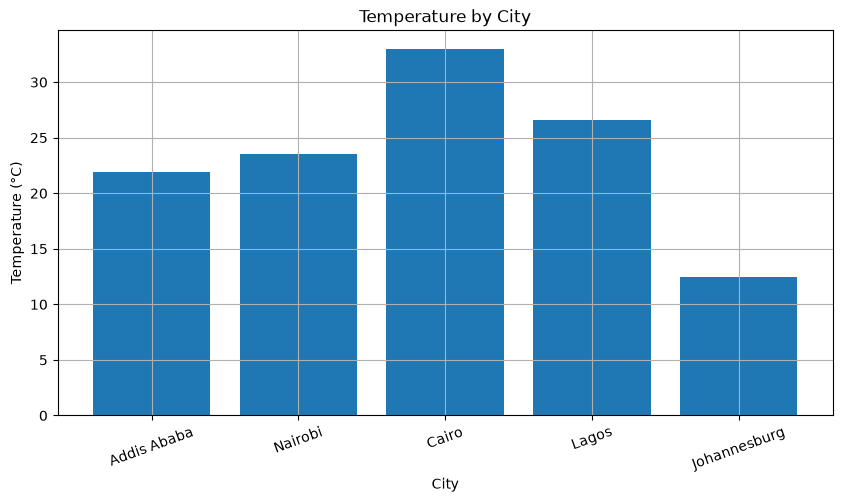

In [33]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))

plt.bar(
    df["City"],
    df["Temperature_C"]
)

plt.title("Temperature by City")

plt.xlabel("City")

plt.ylabel("Temperature (°C)")

plt.xticks(rotation=20)

plt.grid(True)

plt.show()

## Cell 26: Optional Final Analytical Notes

In [34]:
hottest_city = df.loc[df["Temperature_C"].idxmax(), "City"]
coolest_city = df.loc[df["Temperature_C"].idxmin(), "City"]
most_humid_city = df.loc[df["Humidity_Percent"].idxmax(), "City"]

print(f"Hottest city: {hottest_city}")
print(f"Coolest city: {coolest_city}")
print(f"Most humid city: {most_humid_city}")
print(f"Most common weather category: {df['Weather_Category'].mode().iloc[0]}")

Hottest city: Cairo
Coolest city: Johannesburg
Most humid city: Johannesburg
Most common weather category: Warm


## Cell 27: Final Output

In [35]:
print("=" * 60)
print("Weather Data Engineering Pipeline Completed Successfully!")
print("=" * 60)

print(f"Total Cities Processed : {len(df)}")
print(f"Average Temperature    : {df['Temperature_C'].mean():.2f} °C")
print(f"Hottest City           : {df.loc[df['Temperature_C'].idxmax(), 'City']}")
print(f"Coldest City           : {df.loc[df['Temperature_C'].idxmin(), 'City']}")
print(f"Output Files Generated :")
print("- raw_weather.csv")
print("- cleaned_weather.csv")
print("- weather_data.json")
print("- weather_report.csv")

Weather Data Engineering Pipeline Completed Successfully!
Total Cities Processed : 5
Average Temperature    : 23.50 °C
Hottest City           : Cairo
Coldest City           : Johannesburg
Output Files Generated :
- raw_weather.csv
- cleaned_weather.csv
- weather_data.json
- weather_report.csv
